In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
from eofs.xarray import Eof as EOFxr
from eofs.standard import Eof as EOFnumpy
from eofs.multivariate.standard import MultivariateEof as MEOFnumpy
from eofs.multivariate.xarray import MultivariateEOF as MEOFxr

In [3]:
# Use sample camulator data that we are all familiar with from class to illustrate functionality
ds = xr.open_dataset('/Users/wich6609/Downloads/sample_data_camulator.nc')

# Each with dimensions of (time, lat, lon)
ds_U = ds['U'] # Zonal Wind
ds_V = ds['V'] # Meridional Wind
ds_PS = ds['PS'] # Surface Pressure
ds_Q = ds['Qtot'] # Total Column Moisture
ds_TREFHT = ds['TREFHT'] # Near Surface Air Temp
ds_PRECT = ds['PRECT'] # Precipitation

In [4]:
# Variance Visualization -> Single Variables

lats = ds_U['latitude'].values # Take the latitudes from data and convert to values for weighting
lons = ds_U['longitude'].values # I'll do same for longitudes but won't need them for wgts

wgts =  np.cos(np.deg2rad(lats))[np.newaxis , : , np.newaxis] # Weight the data because we are on a sphere. data dims is (time,lat,lon) so I newaxis around the middle

solver_U = EOFxr(ds_U, weights=wgts)
eof1_U = solver_U.eofsAsCorrelation(neofs=1) # I want the leading eof expressed as correlation between the pricipal component time series and data (wind) deviation

solver_V = EOFxr(ds_V, weights=wgts) # Same weighting as U wind because they are on the same grid format
eof1_V = solver_V.eofsAsCorrelation(neofs=1)

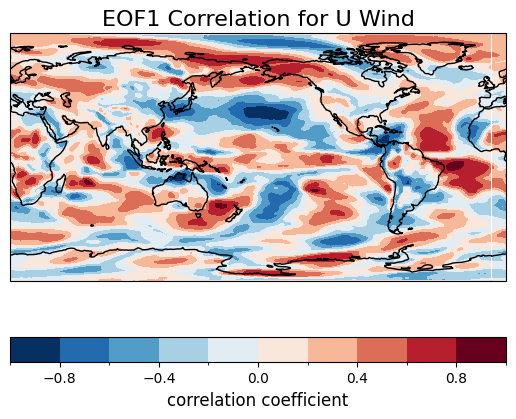

In [5]:
# Following plotting format from Andrew Dawson GitHub code:

clevs = np.linspace(-1, 1, 11)
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=190))
fill = eof1_U[0].plot.contourf(ax=ax, levels=clevs, cmap=plt.cm.RdBu_r, # Plot the first eof dimension index 0
                             add_colorbar=False, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='w', edgecolor='k')
cb = plt.colorbar(fill, orientation='horizontal')
cb.set_label('correlation coefficient', fontsize=12)
ax.set_title('EOF1 Correlation for U Wind', fontsize=16)

ax.coastlines()


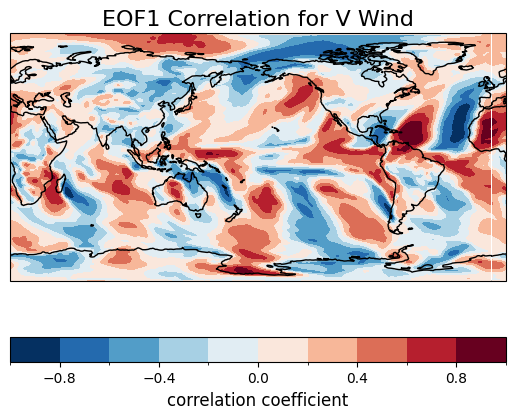

In [6]:
clevs = np.linspace(-1, 1, 11)
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=190))
fill = eof1_V[0].plot.contourf(ax=ax, levels=clevs, cmap=plt.cm.RdBu_r, # Plot the first eof dimension index 0
                             add_colorbar=False, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='w', edgecolor='k')
cb = plt.colorbar(fill, orientation='horizontal')
cb.set_label('correlation coefficient', fontsize=12)
ax.set_title('EOF1 Correlation for V Wind', fontsize=16)

ax.coastlines()

In [7]:
# Multivariate Analysis combining U and V wind
# Since my multivariate analysis file isn't complete, I will need to use the existing file for numpy

mv_solver = MEOFnumpy([ ds_U.to_numpy() , ds_V.to_numpy() ] , weights=[wgts, wgts] )
eof1_UandV = mv_solver.eofsAsCorrelation(neofs=1)

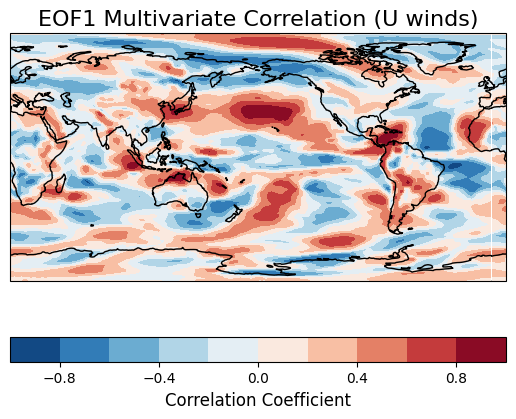

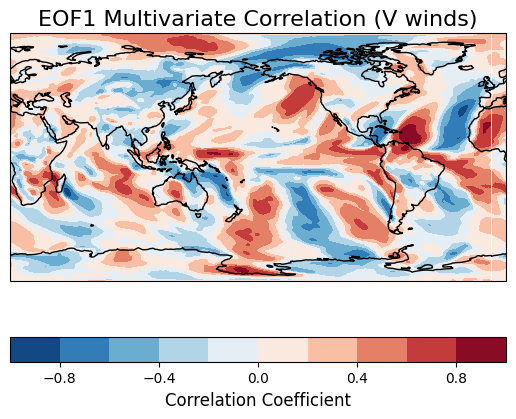

In [10]:
clevs = np.linspace(-1, 1, 11)
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=190))
fill = ax.contourf(lons, lats, eof1_UandV[0][0].squeeze(), clevs, # Leading eof1 for U multivariate analysis. [0][0] is selecting [U][Correlation]
                   transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu_r)

ax.add_feature(cfeature.LAND, facecolor='w', edgecolor='k')

cb = plt.colorbar(fill, orientation='horizontal')
cb.set_label('Correlation Coefficient', fontsize=12)
plt.title('EOF1 Multivariate Correlation (U winds)', fontsize=16)

ax.coastlines()
plt.show()

clevs = np.linspace(-1, 1, 11)
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=190))
fill = ax.contourf(lons, lats, eof1_UandV[1][0].squeeze(), clevs, # Leading eof1 for V multivariate analysis
                   transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu_r)

ax.add_feature(cfeature.LAND, facecolor='w', edgecolor='k')

cb = plt.colorbar(fill, orientation='horizontal')
cb.set_label('Correlation Coefficient', fontsize=12)
plt.title('EOF1 Multivariate Correlation (V winds)', fontsize=16)

ax.coastlines()
plt.show()


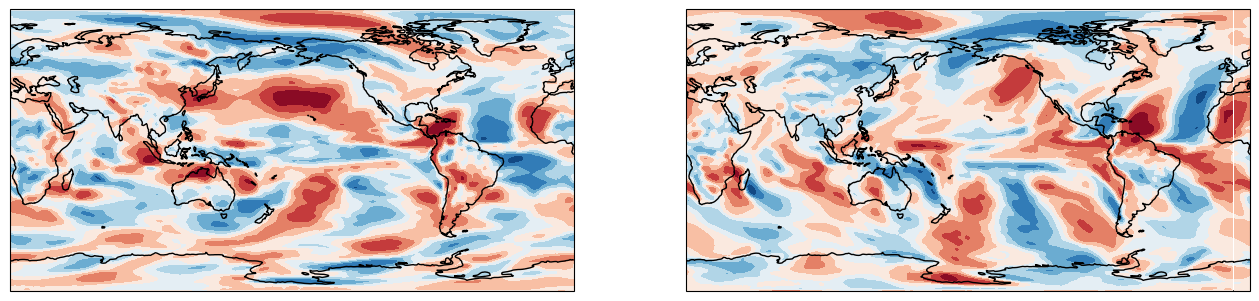

In [11]:
fig, ax = plt.subplots(1,2, subplot_kw={'projection': ccrs.PlateCarree(central_longitude=190)}, figsize=(16,20)) # Define a subplot with 1 row and 2 plots


# ------------------------

clevs = np.linspace(-1, 1, 11)

fill = ax[0].contourf(lons, lats, eof1_UandV[0][0].squeeze(), clevs, # Leading eof1 for U
                   transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu_r)

ax[0].add_feature(cfeature.LAND, facecolor='w', edgecolor='k')

ax[0].coastlines()

# Explains spacial variance for U from multivariate analysis.

# ------------------------

fill = ax[1].contourf(lons, lats, eof1_UandV[1][0].squeeze(), clevs, # Leading eof1 for V
                   transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu_r)

ax[1].add_feature(cfeature.LAND, facecolor='w', edgecolor='k')

ax[1].coastlines()

# Explains spacial variance in V from multivariate analysis.

# ------------------------


In [12]:
print(type(ds_U)) # Zonal wind
print('-------------------------------------')
print(ds_U.dims) # This is an xarray DataArray with 3 dimensions. Data is associated to those grid points along a time series

<class 'xarray.core.dataarray.DataArray'>
-------------------------------------
('time', 'latitude', 'longitude')


In [13]:
ds_U_numpy = ds_U.to_numpy() # Make them numpy arrays to pass through the numpy version
ds_V_numpy = ds_V.to_numpy()

numpy_merged, numpy_info = MEOFnumpy._merge_fields(None, [ds_U_numpy , ds_V_numpy]) # Call the previously existing _merge_fields function designed for numpy arrays
# I need to explicitly pass through a "self" for the function in this case since I'm calling it explicitly. Normally this is done implicitly as part of the __init__ datasets and is
# contained as part of data, info for whatever the inputs were for calling MEOF

print(numpy_merged.shape)
print(type(numpy_merged))
print(numpy_info)


(31, 110592)
<class 'numpy.ndarray'>
{'shapes': [(192, 288), (192, 288)], 'slicers': [slice(0, np.int64(55296), None), slice(np.int64(55296), np.int64(110592), None)]}


In [14]:
# Now my own function!

xr_merged, xr_info = MEOFxr._merge_fields(None, [ds_U , ds_V]) # Call the function I wrote

print(xr_merged.shape)
print(type(xr_merged))
print(xr_merged.dims)
print(xr_info)

(31, 110592)
<class 'xarray.core.dataarray.DataArray'>
('time', 'space')
{'shapes': [(192, 288), (192, 288)], 'slicers': [slice(0, 55296, None), slice(55296, 110592, None)]}


In [15]:
solver_MEOFnumpy = MEOFnumpy( [ ds_U_numpy , ds_V_numpy ] )
solver_MEOFxr = MEOFxr( [ ds_U , ds_V ] )

In [16]:
numpy_eigenvalues = solver_MEOFnumpy.eigenvalues()
xr_eigenvalues = solver_MEOFxr.eigenvalues()

In [17]:
print(numpy_eigenvalues)

[2.62038641e+05 2.12895312e+05 1.59997141e+05 1.41281109e+05
 1.13947836e+05 8.42895156e+04 7.92528906e+04 7.53633672e+04
 6.46430820e+04 5.87666719e+04 5.66498242e+04 4.76953008e+04
 4.36037305e+04 4.07538789e+04 3.88211445e+04 3.33135781e+04
 3.19001367e+04 2.88404414e+04 2.49487051e+04 2.14093750e+04
 2.08335547e+04 2.01403926e+04 1.83686270e+04 1.43825107e+04
 1.37648730e+04 1.26163301e+04 1.10808311e+04 9.96281250e+03
 8.88981055e+03 7.64525293e+03 1.47270747e-08]


In [18]:
print(xr_eigenvalues)

<xarray.DataArray 'eigenvalues' (mode: 31)> Size: 124B
array([2.62038641e+05, 2.12895312e+05, 1.59997141e+05, 1.41281109e+05,
       1.13947836e+05, 8.42895156e+04, 7.92528906e+04, 7.53633672e+04,
       6.46430820e+04, 5.87666719e+04, 5.66498242e+04, 4.76953008e+04,
       4.36037305e+04, 4.07538789e+04, 3.88211445e+04, 3.33135781e+04,
       3.19001367e+04, 2.88404414e+04, 2.49487051e+04, 2.14093750e+04,
       2.08335547e+04, 2.01403926e+04, 1.83686270e+04, 1.43825107e+04,
       1.37648730e+04, 1.26163301e+04, 1.10808311e+04, 9.96281250e+03,
       8.88981055e+03, 7.64525293e+03, 1.47270747e-08], dtype=float32)
Coordinates:
  * mode     (mode) int64 248B 0 1 2 3 4 5 6 7 8 ... 22 23 24 25 26 27 28 29 30
Attributes:
    long_name:  eigenvalues
